<a href="https://colab.research.google.com/github/aliabusohiban/Zillow-Home-Value-Analysis-Time-Series/blob/main/zillow_home_values_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zillow Home Value Analysis — 4 Largest U.S. Cities (2000–2022)

**Business Question:**  
How have typical home values evolved across the 4 largest U.S. cities over the past two decades?  
Specifically, we want to understand:
- Long-term price trends from 2000 to 2022
- Which city had the highest and lowest home values at the end of 2008 (peak of the financial crisis)
- How much home values dropped month-over-month during the crisis (Nov → Dec 2008)

**Dataset:** Zillow Home Value Index (ZHVI) — wide-form time series, one row per city, one column per month  
**Source:** Zillow Research Data (via Google Sheets)

---

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticks
import matplotlib.dates as mdates
import seaborn as sns

# Reproducibility
SEED = 321
np.random.seed(SEED)

# Plot defaults
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_context('talk', font_scale=0.9)

## 2. Helper: X-Axis Date Formatter

This reusable function formats the x-axis with:
- **Minor ticks** every 3 months (labeled by month abbreviation)
- **Major ticks** every year (bold, vertical)
- Distinct gridlines to separate minor/major visually

In [11]:
def format_xdates(ax, fig=None, xtick_fontweight='bold'):
    """Formats x-axis with minor ticks every 3 months and major ticks every year."""
    loc_3months = mdates.MonthLocator(interval=3)
    fmt_months  = mdates.DateFormatter('%b')
    loc_year    = mdates.YearLocator()
    fmt_year    = mdates.DateFormatter('%Y')

    # REMOVED: ax.set_xticks() and ax.set_xticklabels() — these break datetime axis

    ax.xaxis.set_minor_locator(loc_3months)
    ax.xaxis.set_minor_formatter(fmt_months)
    ax.xaxis.set_major_locator(loc_year)
    ax.xaxis.set_major_formatter(fmt_year)

    ax.grid(which='minor', axis='x', ls=':')
    ax.grid(which='major', axis='x', color='k')

    if fig is None:
        fig = ax.get_figure()
    fig.autofmt_xdate(which='major', rotation=90, ha='center')
    return fig, ax

## 3. Load Data

The Zillow dataset arrives in **wide form**: each row is a city, each column is a month.  
There are 22,467 cities and 281 columns (8 metadata + 273 monthly timestamps from Jan 2000 to Sep 2022).

In [3]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQN3Ksa9szQuO4G1-msXWAp17KtVHQCBnuEieu_auu1wSiBf3-krHusIx5VBMkihxj-KZLBosDIGEyR/pub?output=csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
df.head(4)

Shape: (22467, 281)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0,234401.0,...,924019.0,928991.0,937936.0,953874.0,973168.0,990391.0,992337.0,992630.0,978196.0,966595.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0,109079.0,...,245783.0,248718.0,252080.0,256435.0,261101.0,265558.0,268901.0,271059.0,272400.0,272639.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0,166536.0,...,302821.0,305104.0,306404.0,308303.0,309649.0,312487.0,314663.0,315910.0,315587.0,315429.0


## 4. Filter to the 4 Largest Cities

`SizeRank` is 0-indexed. Ranks 0–3 correspond to:  
**New York, Los Angeles, Houston, Chicago**

We use `SizeRank < 4` to keep only these four rows.

In [4]:
df = df.loc[df['SizeRank'] < 4].reset_index(drop=True)
print(f'Cities selected: {df["RegionName"].tolist()}')
df[['RegionName', 'State', 'SizeRank']].head()

Cities selected: ['New York', 'Los Angeles', 'Houston', 'Chicago']


,RegionName,State,SizeRank
0,New York,NY,0
1,Los Angeles,CA,1
2,Houston,TX,2
3,Chicago,IL,3


## 5. Reshape: Wide → Long Form

Time series analysis in pandas requires **long form**: one row per (city, date) observation.  
We use `pd.melt()` to collapse all monthly columns into two columns: `Date` and `HomePrice`.  
The 8 metadata columns become `id_vars` (kept intact per row).

In [5]:
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName']

df_long = pd.melt(
    df,
    id_vars=id_cols,
    var_name='Date',
    value_name='HomePrice'
)

print(f'Long-form shape: {df_long.shape}')
df_long.head()

Long-form shape: (1092, 10)


,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,HomePrice
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,253690.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,2000-01-31,234181.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,109068.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,2000-01-31,166139.0
4,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-02-29,255517.0


## 6. Build the Time Series Index

We convert `Date` to a proper `datetime` type and set it as the index.  
Then we group by city and resample to monthly frequency (`MS` = month start) to ensure a clean, uniform time series with no gaps.

In [6]:
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long = df_long.set_index('Date')

# Group by city, resample monthly, take mean (single value per city/month anyway)
monthly = (
    df_long
    .groupby('RegionName')['HomePrice']
    .resample('MS')
    .mean()
)

print('MultiIndex structure:')
print(monthly.index[:4])
monthly.head(8)

MultiIndex structure:
MultiIndex([('Chicago', '2000-01-01'),
            ('Chicago', '2000-02-01'),
            ('Chicago', '2000-03-01'),
            ('Chicago', '2000-04-01')],
           names=['RegionName', 'Date'])


RegionName  Date      
Chicago     2000-01-01    166139.0
            2000-02-01    166536.0
            2000-03-01    167368.0
            2000-04-01    168826.0
            2000-05-01    170499.0
            2000-06-01    172008.0
            2000-07-01    173598.0
            2000-08-01    175282.0
Name: HomePrice, dtype: float64

## 7. Unstack for Plotting

With a MultiIndex `(RegionName, Date)`, pandas can't draw a separate line per city.  
We use `.unstack(level=0)` to pivot `RegionName` into columns, making `Date` the sole index.  
This gives us one column per city — exactly what `.plot()` needs.

In [7]:
plot_df = monthly.unstack(level=0)
print('Unstacked shape:', plot_df.shape)
plot_df.head()

Unstacked shape: (273, 4)


RegionName,Chicago,Houston,Los Angeles,New York
Date,,,,
2000-01-01,166139.0,109068.0,234181.0,253690.0
2000-02-01,166536.0,109079.0,234401.0,255517.0
2000-03-01,167368.0,108878.0,235513.0,257207.0
2000-04-01,168826.0,108881.0,237589.0,260310.0
2000-05-01,170499.0,108834.0,240113.0,263204.0


## 8. Visualization — Home Values 2000–2022

Key formatting choices:
- **Y-axis** uses a `FuncFormatter` to display values in thousands (e.g. `$400K`) instead of raw numbers
- **X-axis** uses the `format_xdates()` helper for year/quarter gridlines
- Each city gets its own line color via the default matplotlib color cycle

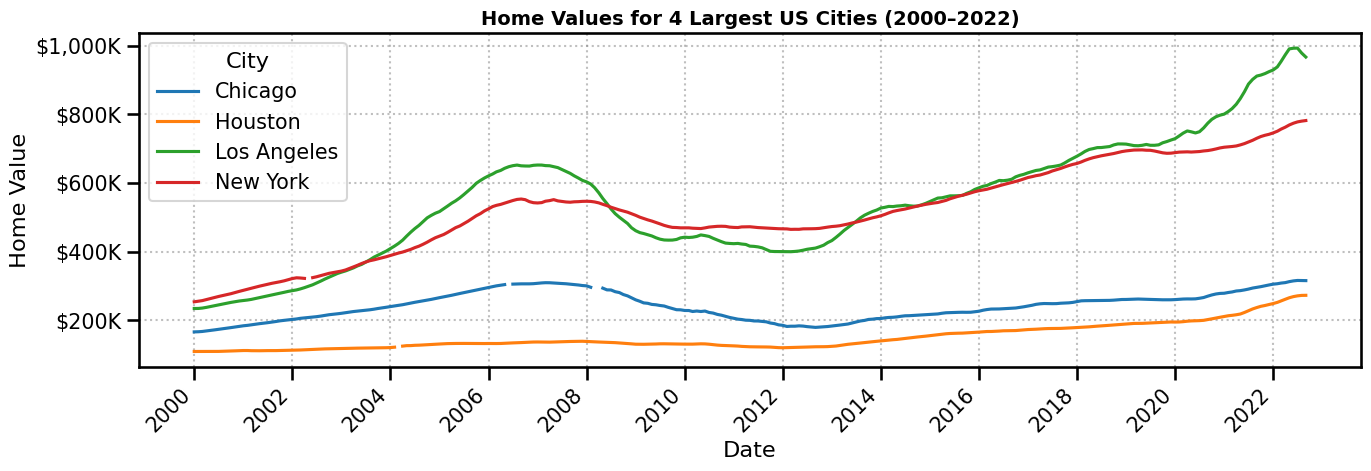

In [14]:
def dollar_thousands(x, pos):
    return f'${x / 1_000:,.0f}K'

fmt_thous = mticks.FuncFormatter(dollar_thousands)

fig, ax = plt.subplots(figsize=(14, 5))

for city in plot_df.columns:
    ax.plot(plot_df.index, plot_df[city], label=city)

ax.set_title('Home Values for 4 Largest US Cities (2000–2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Home Value')
ax.yaxis.set_major_formatter(fmt_thous)
ax.legend(title='City')

# Major ticks: every 2 years only, no minor ticks
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Light vertical gridlines per major tick only
ax.grid(which='major', axis='x', ls=':', color='gray', alpha=0.5)
ax.grid(which='major', axis='y', ls=':', color='gray', alpha=0.5)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observations

The plot reveals three distinct phases across all four cities:

**2000–2006 — The Housing Boom:**  
Los Angeles and New York surged aggressively, with LA nearly tripling from ~$230K to ~$650K.
Chicago grew moderately while Houston remained flat, suggesting the bubble was concentrated
in high-demand coastal markets.

**2006–2012 — The Crash and Aftermath:**  
LA dropped the hardest, losing roughly $200K in value. New York declined more gradually.
Chicago fell steadily through 2012. Houston barely moved — its lower price point and
oil-driven economy insulated it from the worst of the crash.

**2012–2022 — Recovery and Acceleration:**  
All four cities recovered and surpassed pre-crisis peaks. The post-COVID period (2020–2022)
produced the steepest single acceleration on record, with LA crossing $1M and New York
approaching $800K by late 2022.

## 9. Analysis — Snapshot at the 2008 Financial Crisis

**Question 1:** Which city had the highest and lowest typical home value at the end of 2008?  

December 2008 marked the trough of the U.S. housing market collapse triggered by the subprime mortgage crisis.  
We slice the unstacked DataFrame at that date to get a cross-city snapshot.

In [9]:
dec_2008 = plot_df.loc['2008-12-01']

print('=== Home Values — December 2008 ===')
print(dec_2008.apply(lambda x: f'${x:,.0f}').to_string())
print(f'\nHighest: {dec_2008.idxmax()} — ${dec_2008.max():,.0f}')
print(f'Lowest:  {dec_2008.idxmin()} — ${dec_2008.min():,.0f}')

=== Home Values — December 2008 ===
RegionName
Chicago        $265,306
Houston        $131,283
Los Angeles    $469,294
New York       $510,309

Highest: New York — $510,309
Lowest:  Houston — $131,283


**Question 2:** How much did home values change from November to December 2008?

`.diff()` computes the row-by-row difference across the time axis.  
Slicing at `2008-12-01` after applying `.diff()` gives us exactly `Dec_value - Nov_value` for each city.  
A negative number means the home value fell that month.

In [10]:
diff_df = plot_df.diff()
nov_to_dec = diff_df.loc['2008-12-01']

print('=== Month-over-Month Change: Nov → Dec 2008 ===')
for city, change in nov_to_dec.items():
    direction = 'increased' if change > 0 else 'decreased'
    print(f'{city}: {direction} by ${abs(change):,.0f}')

=== Month-over-Month Change: Nov → Dec 2008 ===
Chicago: decreased by $5,753
Houston: decreased by $964
Los Angeles: decreased by $12,611
New York: decreased by $4,458


## 10. Summary of Findings

**Q1 — Home Values at End of 2008 (December 2008)**

| City | Home Value |
|---|---|
| New York | 510,309 — **Highest** |
| Los Angeles | 469,294 |
| Chicago | 265,306 |
| Houston | 131,283 — **Lowest** |

**Q2 — Month-over-Month Change: Nov → Dec 2008**

| City | Change |
|---|---|
| Los Angeles | decreased by 12,611 — largest drop |
| Chicago | decreased by 5,753 |
| New York | decreased by 4,458 |
| Houston | decreased by 964 — smallest drop |

**Key observations:**
- Los Angeles led the bubble-and-bust pattern most dramatically, peaking near $650K
  around 2006–2007 before falling sharply.
- Houston showed the most stability during the crisis — low starting values and smaller
  absolute drops.
- New York held the highest values throughout but also saw significant declines.
- All four cities recovered and surpassed their pre-crisis peaks by 2018–2019, with the
  post-COVID period (2020–2022) driving another steep acceleration.

---
*Data: Zillow Home Value Index (ZHVI) | Analysis period: Jan 2000 – Sep 2022*